### Question

Create a data pipeline for this dataset 
https://www.kaggle.com/datasets/sriharshaeedala/airline-delay/data

which should include following
- Extract (load csv)
- Transform (clean data and transform data if needed)
- Load (save the cleaned data in csv file)

Also create visualization of 
- correlation of attributes
- distribution of values in attributes 
- and any 3 other graph using seaborn 

Note: Also generate insight from it and explain it. 

Submission should be done in github repo with ipynb file or google collab link.


---

### Dataset Description

The dataset is structured as a tabular format with rows representing unique combinations of year, month, carrier, and airport. Each row contains information on various metrics, including flight counts, delay counts, cancellation and diversion counts, and delay breakdowns by different factors. The columns provide specific details such as carrier codes and names, airport codes and names, and counts of delays attributed to carrier, weather, NAS, security, and late aircraft arrivals. The structured format ensures that users can easily query, analyze, and visualize the data to derive meaningful insights.

- year: The year of the data.
- month: The month of the data.
- carrier: Carrier code.
- carrier_name: Carrier name.
- airport: Airport code.
- airport_name: Airport name.
- arr_flights: Number of arriving flights.
- arr_del15: Number of flights delayed by 15 minutes or more.
- carrier_ct: Carrier count (delay due to the carrier).
- weather_ct: Weather count (delay due to weather).
- nas_ct: NAS (National Airspace System) count (delay due to the NAS).
- security_ct: Security count (delay due to security).
- late_aircraft_ct: Late aircraft count (delay due to late aircraft arrival).
- arr_cancelled: Number of flights canceled.
- arr_diverted: Number of flights diverted.
- arr_delay: Total arrival delay.
- carrier_delay: Delay attributed to the carrier.
- weather_delay: Delay attributed to weather.
- nas_delay: Delay attributed to the NAS.
- security_delay: Delay attributed to security.
- late_aircraft_delay: Delay attributed to late aircraft arrival.

---

## STEP 1: EXTRACT

### 1.1 loading the data from kaggle


In [1]:
# importing the necessary libraries for ETL process
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
# boilerplate code from kaggle to load the dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Airline_Delay_Cause.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sriharshaeedala/airline-delay",
  file_path
)

/Users/paru/Documents/data science stuffs/yappascience/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# verifying if data is properly loaded or not
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [4]:
df.tail()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
171661,2013,8,YV,Mesa Airlines Inc.,TRI,"Bristol/Johnson City/Kingsport, TN: Tri Cities",7.0,1.0,0.78,0.0,...,0.0,0.0,0.0,0.0,23.0,18.0,0.0,5.0,0.0,0.0
171662,2013,8,YV,Mesa Airlines Inc.,YUM,"Yuma, AZ: Yuma MCAS/Yuma International",2.0,1.0,0.00,0.0,...,0.0,1.0,0.0,0.0,17.0,0.0,0.0,0.0,0.0,17.0
171663,2013,8,YV,Mesa Airlines Inc.,SLC,"Salt Lake City, UT: Salt Lake City International",2.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
171664,2013,8,DL,Delta Air Lines Inc.,SBN,"South Bend, IN: South Bend International",1.0,1.0,1.00,0.0,...,0.0,0.0,0.0,0.0,18.0,18.0,0.0,0.0,0.0,0.0
171665,2013,8,F9,Frontier Airlines Inc.,MTJ,"Montrose/Delta, CO: Montrose Regional",1.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.2 performing data validation

In [5]:
# total rows
total_data = len(df)  
total_data

171666

In [6]:
# getting the statistics of numerical columns
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
year,171666.0,2018.551361,2.890006,2013.0,2016.00,2019.00,2021.00,2023.00
month,171666.0,6.493633,3.440908,1.0,4.00,7.00,9.00,12.00
arr_flights,171426.0,362.528467,992.894662,1.0,50.00,100.00,250.00,21977.00
arr_del15,171223.0,66.434387,179.540694,0.0,6.00,17.00,47.00,4176.00
carrier_ct,171426.0,20.796615,50.315176,0.0,2.16,6.40,17.26,1293.91
weather_ct,171426.0,2.250347,7.314252,0.0,0.00,0.40,1.86,266.42
nas_ct,171426.0,19.381147,61.675244,0.0,1.00,3.91,11.71,1884.42
security_ct,171426.0,0.157096,0.717405,0.0,0.00,0.00,0.00,58.69
late_aircraft_ct,171426.0,23.770554,72.393477,0.0,1.23,5.00,15.26,2069.07
arr_cancelled,171426.0,7.530497,43.654880,0.0,0.00,1.00,4.00,4951.00


In [7]:
print(df.dtypes)

year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object


In [8]:
# checking if delay minutes and number of delays are same or not and
for i in range(20):
    index = np.random.randint(0, total_data)
    count, cc,wc,nc,sc,lac = df.loc[index, ['arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']]
    mins, cm,wm,nm,sm,lm = df.loc[index, ['arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']]
    if mins != round(cm+wm+nm+sm+lm):
        print(f'{index}: Minutes NOT matched')
        print(f'T:{mins} : {cm}, {wm}, {nm}, {sm}, {lm} : {cm+wm+nm+sm+lm}')
    if count != round(cc+wc+nc+sc+lac):
         print(f'{index}: Count NOT matched')
         print(f'T:{count} : {cc}, {wc}, {nc}, {sc}, {lac}: {cc+wc+nc+sc+lac}')
    

In [9]:
# total percentage of data that is null
null_values = df.isna().sum()
print('columns \t\t\t nullvalues%')
for i in range(len(null_values)):
    print(f'{null_values.index[i]} \t\t\t {round(null_values[i]/total_data*100, 3)}%')

columns 			 nullvalues%
year 			 0.0%
month 			 0.0%
carrier 			 0.0%
carrier_name 			 0.0%
airport 			 0.0%
airport_name 			 0.0%
arr_flights 			 0.14%
arr_del15 			 0.258%
carrier_ct 			 0.14%
weather_ct 			 0.14%
nas_ct 			 0.14%
security_ct 			 0.14%
late_aircraft_ct 			 0.14%
arr_cancelled 			 0.14%
arr_diverted 			 0.14%
arr_delay 			 0.14%
carrier_delay 			 0.14%
weather_delay 			 0.14%
nas_delay 			 0.14%
security_delay 			 0.14%
late_aircraft_delay 			 0.14%


/var/folders/lq/wz2w0wfj3gn14q_q15mhm9sc0000gn/T/ipykernel_4420/2139138028.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f'{null_values.index[i]} \t\t\t {round(null_values[i]/total_data*100, 3)}%')


In [10]:
# looking at random set of data
df.iloc[135:145,:]

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
135,2023,8,AA,American Airlines Inc.,FLL,"Fort Lauderdale, FL: Fort Lauderdale-Hollywood...",447.0,129.0,40.22,3.59,...,0.25,57.76,5.0,3.0,11667.0,3675.0,514.0,1169.0,9.0,6300.0
136,2023,8,AA,American Airlines Inc.,FSD,"Sioux Falls, SD: Joe Foss Field",62.0,25.0,9.74,0.00,...,0.00,10.11,0.0,0.0,2900.0,800.0,0.0,344.0,0.0,1756.0
137,2023,8,AA,American Airlines Inc.,GEG,"Spokane, WA: Spokane International",93.0,25.0,10.35,0.00,...,0.00,10.84,1.0,0.0,3519.0,714.0,0.0,143.0,0.0,2662.0
138,2023,8,AA,American Airlines Inc.,GRR,"Grand Rapids, MI: Gerald R. Ford International",166.0,56.0,17.95,1.69,...,0.00,31.22,2.0,2.0,8476.0,2361.0,76.0,263.0,0.0,5776.0
139,2023,8,AA,American Airlines Inc.,GSO,"Greensboro/High Point, NC: Piedmont Triad Inte...",122.0,33.0,11.03,1.49,...,0.05,16.20,1.0,0.0,3809.0,496.0,169.0,154.0,3.0,2987.0
140,2023,8,AA,American Airlines Inc.,GSP,"Greer, SC: Greenville-Spartanburg International",123.0,44.0,10.40,4.01,...,0.11,26.85,0.0,0.0,3849.0,753.0,324.0,122.0,27.0,2623.0
141,2023,8,AA,American Airlines Inc.,HNL,"Honolulu, HI: Daniel K Inouye International",186.0,41.0,14.52,0.00,...,0.00,11.55,0.0,2.0,2878.0,959.0,0.0,370.0,0.0,1549.0
142,2023,8,AA,American Airlines Inc.,HSV,"Huntsville, AL: Huntsville International-Carl ...",9.0,5.0,1.28,0.00,...,0.00,3.70,0.0,0.0,581.0,125.0,0.0,3.0,0.0,453.0
143,2023,8,AA,American Airlines Inc.,IAD,"Washington, DC: Washington Dulles International",76.0,12.0,4.85,0.75,...,0.00,5.73,0.0,0.0,834.0,338.0,49.0,23.0,0.0,424.0
144,2023,8,AA,American Airlines Inc.,IAH,"Houston, TX: George Bush Intercontinental/Houston",683.0,180.0,75.08,8.10,...,0.00,77.69,8.0,1.0,17333.0,7728.0,838.0,1105.0,0.0,7662.0


In [11]:
# checking if unique or not
pk_columns = ['year', 'month', 'carrier', 'airport']
duplicate_count = df.duplicated(subset=pk_columns).sum()
duplicate_count

np.int64(0)

In [12]:
delay_ct_cols = ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct']
delay_mins_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

zero_delay_ct_rows = df[(df[delay_ct_cols] == 0).all(axis=1)]
zero_delay_mins_rows = df[(df[delay_mins_cols] == 0).all(axis=1)]
zero_total_delay_ct = df[(df['arr_delay'] == 0)]
zero_total_delay_mins = df[(df['arr_del15'] == 0)]

print(f"Rows where all delay causes count is 0: {len(zero_delay_ct_rows)} ")
print(f"Total 0 count: {len(zero_total_delay_ct)}")
print("---")
print(f"Rows where all delay mins is 0: {len(zero_delay_mins_rows)} ")
print(f"Total 0 mins: {len(zero_total_delay_mins)}")


Rows where all delay causes count is 0: 6788 
Total 0 count: 6788
---
Rows where all delay mins is 0: 6788 
Total 0 mins: 6585


In [13]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
all_zero_numeric = df[
    (df[numeric_cols] == 0).all(axis=1)
]

print("Rows where all numeric values are zero:", len(all_zero_numeric))

Rows where all numeric values are zero: 0


In [14]:
invalid_delay_rows = df[df['arr_del15'] > df['arr_flights']]
print("Invalid delay rows:", len(invalid_delay_rows))

Invalid delay rows: 0


### From initial exploration, following things are deduced:

1. Total rows: 171,666
2. All columns are in the respective datatypes i.e. numerical columns in int and float, string columns in object
3. For non-null values, the total delay count and total delay minutes is exactly the sum of different causes of counts of delay and minutes of delay
4. Around 0.14% of most columns is null, however max is of arr_del15 with 0.258%
5. Primary key for this dataset: (year, month, carrier, airport)
6. NO duplicate values
7. 6788 instances had no delay. However, 6585 instances are sure to have no delays but the random 200-ish datapoints seem illogical
8. Complete null rows: 0

---

## STEP 2: TRANSFORM AND VISUALIZE

### 2.1 Data Cleaning

In [15]:
# remove null data since its very few compared to the total data
df = df.dropna()

In [16]:
# since airport_name contains info as location_of_airport : name_of_airport
temp_df = df['airport_name'].str.split(pat=":", expand=True)
temp_df.head()
df['airport_location'] = temp_df[0]
df['airport_name'] = temp_df[1]

In [17]:
# converting each of the columns

# categorical data to category instead of object
df['carrier'] = df['carrier'].astype('category')
df['carrier_name'] = df['carrier_name'].astype('category')
df['airport'] = df['airport'].astype('category')
df['airport_name'] = df['airport_name'].astype('category')

# cancelled and diverted values to int
df['arr_cancelled'] = df['arr_cancelled'].astype(int)
df['arr_diverted'] = df['arr_diverted'].astype(int)

# minutes
df['arr_delay'] = df['arr_delay'].astype(int)
df['carrier_delay'] = df['carrier_delay'].astype(int)
df['weather_delay'] = df['weather_delay'].astype(int)
df['nas_delay'] = df['nas_delay'].astype(int)
df['security_delay'] = df['security_delay'].astype(int)
df['late_aircraft_delay'] = df['late_aircraft_delay'].astype(int)

In [18]:
# adding new date column for time series plotting later
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')
df['date'].head()

0   2023-08-01
1   2023-08-01
2   2023-08-01
3   2023-08-01
4   2023-08-01
Name: date, dtype: datetime64[ns]

### 2.2 Outlier Detection

using just the regular box plot had so many outliers because some airports are really huge compared to the others and thus log transformation is performed to get it into a reasonable level

In [19]:
# for col in numeric_cols:
#     sns.boxplot(x=np.log1p(df[col]))
#     plt.show()

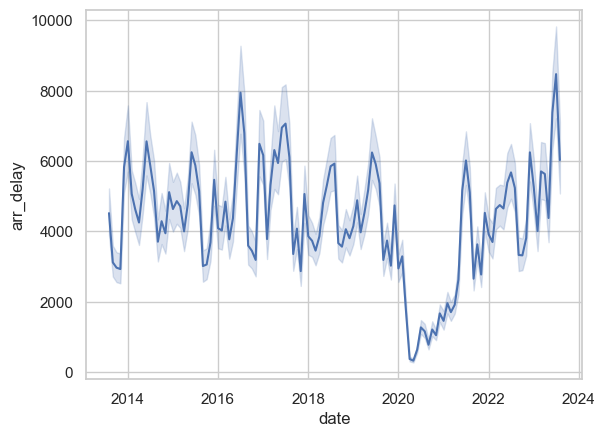

In [20]:
sns.lineplot(data=df, x='date', y='arr_delay')
plt.show()

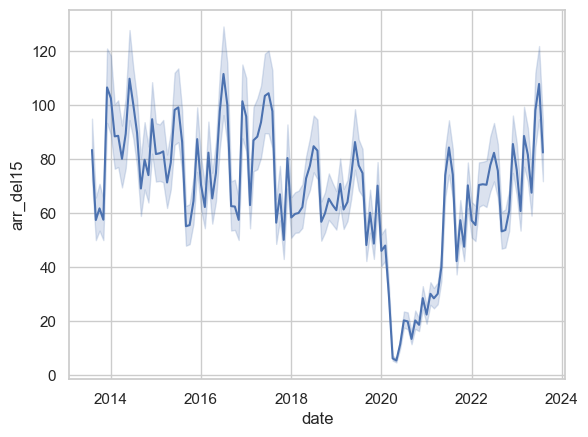

In [21]:
sns.lineplot(data=df, x='date', y='arr_del15')
plt.show()

<Axes: xlabel='date', ylabel='delay_rate'>

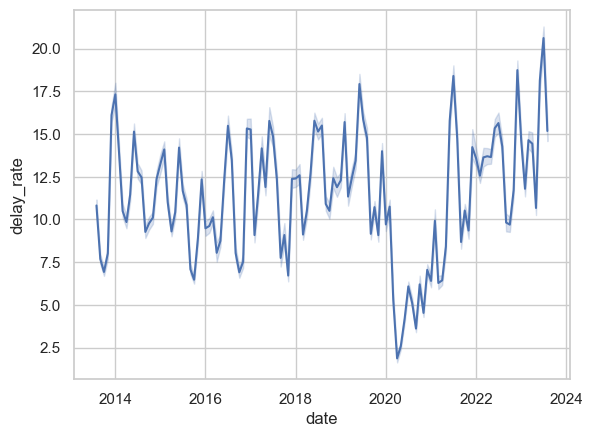

In [22]:
# avg proportion of delay per data
df['delay_rate'] = df['arr_delay'] / df['arr_flights'] 
sns.lineplot(data=df, x='date', y='delay_rate')

In [23]:
top_airports = (
    df.groupby('airport_name')['arr_flights']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

top_airports

/var/folders/lq/wz2w0wfj3gn14q_q15mhm9sc0000gn/T/ipykernel_4420/1058753228.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('airport_name')['arr_flights']


CategoricalIndex([' Hartsfield-Jackson Atlanta International',
                  ' Chicago O'Hare International',
                  ' Dallas/Fort Worth International', ' Denver International',
                  ' Los Angeles International'],
                 categories=[' Aberdeen Regional', ' Abilene Regional', ' Abraham Lincoln Capital', ' Adak', ..., ' Yellowstone', ' Yellowstone Regional', ' Youngstown-Warren Regional', ' Yuma MCAS/Yuma International'], ordered=False, dtype='category', name='airport_name')

Index([' Chicago O'Hare International', ' Dallas/Fort Worth International',
       ' Denver International', ' Hartsfield-Jackson Atlanta International',
       ' Los Angeles International'],
      dtype='object')


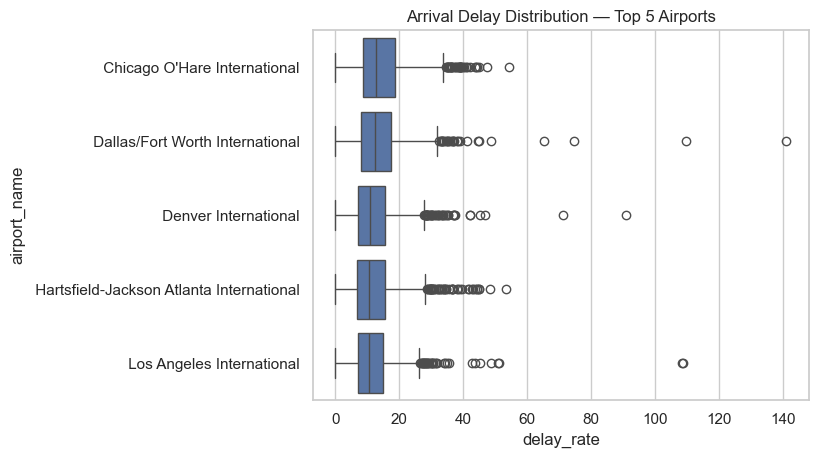

In [24]:
df_top = df[df['airport_name'].isin(top_airports)].copy()
df_top['airport_name'] = df_top['airport_name'].cat.remove_unused_categories()

print(df_top['airport_name'].cat.categories)
sns.boxplot(data=df_top, y='airport_name', x='delay_rate')

plt.title("Arrival Delay Distribution — Top 5 Airports")
plt.show()


/var/folders/lq/wz2w0wfj3gn14q_q15mhm9sc0000gn/T/ipykernel_4420/1264170222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('airport_name')['arr_flights']


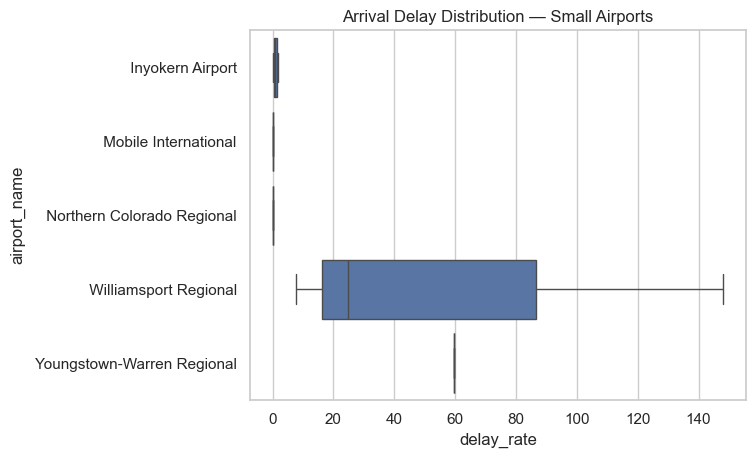

In [25]:
small_airports = (
    df.groupby('airport_name')['arr_flights']
      .sum()
      .sort_values()
      .head(5)
      .index
)

df_small = df[df['airport_name'].isin(small_airports)].copy()
df_small['airport_name'] = df_small['airport_name'].cat.remove_unused_categories()
sns.boxplot(data=df_small, y='airport_name', x='delay_rate')
plt.title("Arrival Delay Distribution — Small Airports")
plt.show()

/var/folders/lq/wz2w0wfj3gn14q_q15mhm9sc0000gn/T/ipykernel_4420/2102527486.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('carrier_name')['arr_flights']


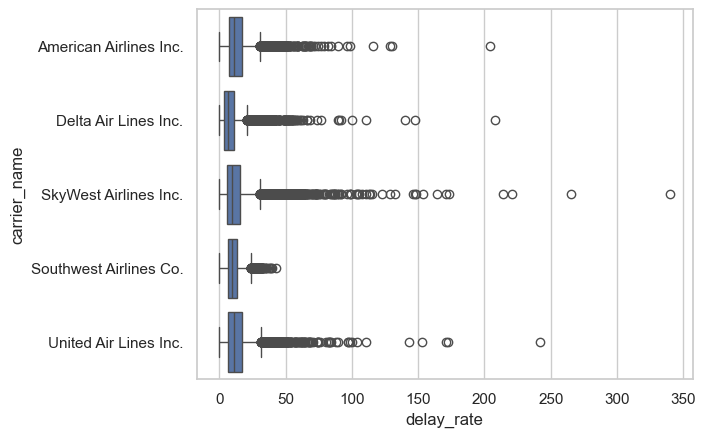

In [26]:
top_carriers = (
    df.groupby('carrier_name')['arr_flights']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

df_carrier = df[df['carrier_name'].isin(top_carriers)].copy()
df_carrier['carrier_name'] = df_carrier['carrier_name'].cat.remove_unused_categories()
sns.boxplot(data=df_carrier, y='carrier_name', x='delay_rate')
plt.show()

since data is heavily right skewed, we dont remove the outliers and use domain knowledge to make proper sense of it.

### 2.3 Feature Engineering

In [27]:
df['cancellation_rate'] = df['arr_cancelled'] / df['arr_flights']
df['diverted_rate'] = df['arr_diverted'] / df['arr_flights']

for col in delay_ct_cols:
    title = col.replace('_ct', '_rate')
    df[title] = df[col] / df['arr_flights']

In [28]:
# since american month, convert to american seasons
month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 
    5: 'May', 6: 'June', 7: 'July', 8: 'August', 
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

season_map = {
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall',
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter'
}
df['month_name'] = df['month'].map(month_map)
df['season'] = df['month_name'].map(season_map)


In [29]:
# carrier summary generation using groupby

carrier_summary = (
    df.groupby('carrier_name')
      .agg(
          total_flights=('arr_flights', 'sum'),
          total_delay=('arr_delay', 'sum'),
          total_cancelled=('arr_cancelled', 'sum'),
          total_diverted=('arr_diverted', 'sum')
      )
)

carrier_summary['avg_delay'] = (carrier_summary['total_delay'] / carrier_summary['total_flights'])
carrier_summary['cancellation_rate'] = (carrier_summary['total_cancelled'] / carrier_summary['total_flights'])
carrier_summary['diverted_rate'] = (carrier_summary['total_diverted'] / carrier_summary['total_flights'])
carrier_summary = carrier_summary.sort_values(by='avg_delay', ascending=False)
carrier_summary.sort_values('avg_delay', ascending=True).head()

/var/folders/lq/wz2w0wfj3gn14q_q15mhm9sc0000gn/T/ipykernel_4420/2157185386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('carrier_name')


,total_flights,total_delay,total_cancelled,total_diverted,avg_delay,cancellation_rate,diverted_rate
carrier_name,,,,,,,
Hawaiian Airlines Inc.,727264.0,3936732,4849,682,5.413071,0.006667,0.000938
Horizon Air,200419.0,1454145,3608,330,7.255525,0.018002,0.001647
Alaska Airlines Inc.,1990956.0,15640396,25876,5184,7.855722,0.012997,0.002604
US Airways Inc.,784157.0,6507284,12167,1364,8.298445,0.015516,0.001739
AirTran Airways Corporation,143429.0,1202869,1812,251,8.386512,0.012633,0.001750


In [30]:
airport_summary = (
    df.groupby('airport_name')
      .agg(
          total_flights=('arr_flights', 'sum'),
          total_delay=('arr_delay', 'sum'),
          total_cancelled=('arr_cancelled', 'sum')
      )
)

airport_summary['avg_delay'] = (airport_summary['total_delay'] / airport_summary['total_flights'])

airport_summary.sort_values('avg_delay', ascending=True).head()

/var/folders/lq/wz2w0wfj3gn14q_q15mhm9sc0000gn/T/ipykernel_4420/3817906235.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('airport_name')


,total_flights,total_delay,total_cancelled,avg_delay
airport_name,,,,
Mobile International,12.0,0,0,0.000000
Northern Colorado Regional,1.0,0,0,0.000000
Inyokern Airport,160.0,184,13,1.150000
Hilo International,60294.0,230542,430,3.823631
Francisco C. Ada Saipan International,1889.0,7701,20,4.076760


In [31]:
yearly_trend = (
    df.groupby('year')
      .agg(
          total_flights=('arr_flights', 'sum'),
          total_delay=('arr_delay', 'sum')
      )
)

yearly_trend['avg_delay'] = (yearly_trend['total_delay'] / yearly_trend['total_flights'])

yearly_trend

,total_flights,total_delay,avg_delay
year,,,
2013,2629105.0,26106070,9.929641
2014,5819810.0,70316961,12.082347
2015,5819076.0,62651867,10.766635
2016,5617655.0,59850360,10.653976
2017,5674615.0,65816682,11.598440
2018,7206192.0,87498074,12.142068
2019,7422029.0,95889721,12.919610
2020,4686372.0,26909950,5.742171
2021,5995392.0,66613311,11.110752


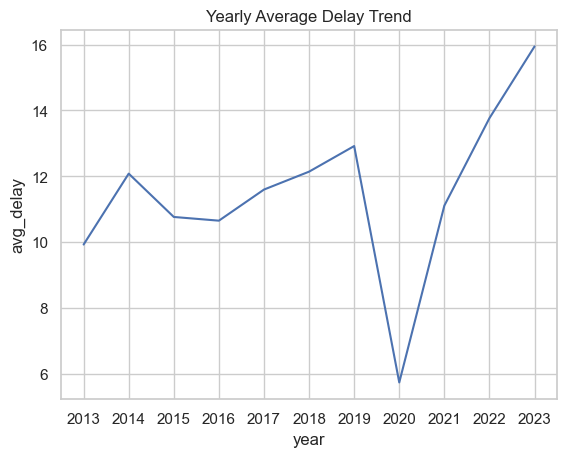

In [32]:
sns.lineplot(data=yearly_trend, x=yearly_trend.index, y='avg_delay')
plt.title("Yearly Average Delay Trend")
plt.xticks([2013, 2014,2015,2016,2017,2018,2019,2020,2021,2022,2023])
plt.show()

In [33]:
monthly_trend = (
    df.groupby('month_name')
      .agg(
          total_flights=('arr_flights', 'sum'),
          total_delay=('arr_delay', 'sum'),
          numerical = ('month', 'min')
      )
)

monthly_trend['avg_delay'] = (monthly_trend['total_delay'] / monthly_trend['total_flights'])

monthly_trend = monthly_trend.sort_values('numerical', ascending=True)
monthly_trend

,total_flights,total_delay,numerical,avg_delay
month_name,,,,
January,5037378.0,59505501,1,11.812792
February,4653336.0,54782130,2,11.772657
March,5457765.0,56283576,3,10.312569
April,4986961.0,54493614,4,10.927219
May,5049760.0,58248429,5,11.534891
June,5175723.0,79834292,6,15.424761
July,5490435.0,83779210,7,15.259121
August,6033999.0,79871501,8,13.236910
September,4969474.0,42227639,9,8.497406


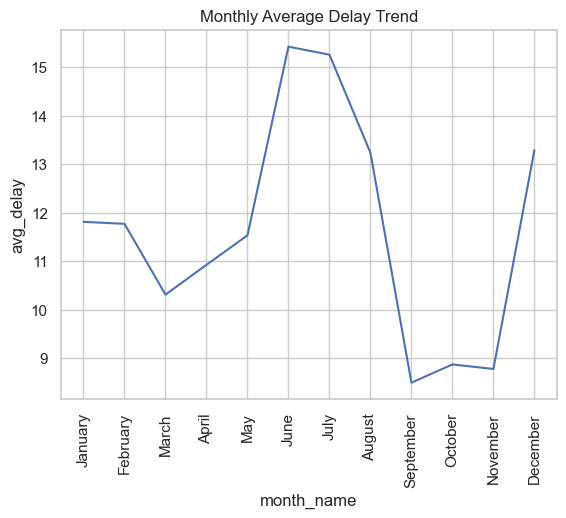

In [34]:
sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='avg_delay')
plt.title("Monthly Average Delay Trend")
plt.xticks(rotation=90)
plt.show()

In [35]:
seasonal_trend = (
    df.groupby('season')
      .agg(
          total_flights=('arr_flights', 'sum'),
          total_delay=('arr_delay', 'sum')
      )
)

seasonal_trend['avg_delay'] = (seasonal_trend['total_delay'] / seasonal_trend['total_flights'])
seasonal_trend

,total_flights,total_delay,avg_delay
season,,,
Fall,15161172.0,132195745,8.719362
Spring,15494486.0,169025619,10.908759
Summer,16700157.0,243485003,14.579803
Winter,14788961.0,182051988,12.309992


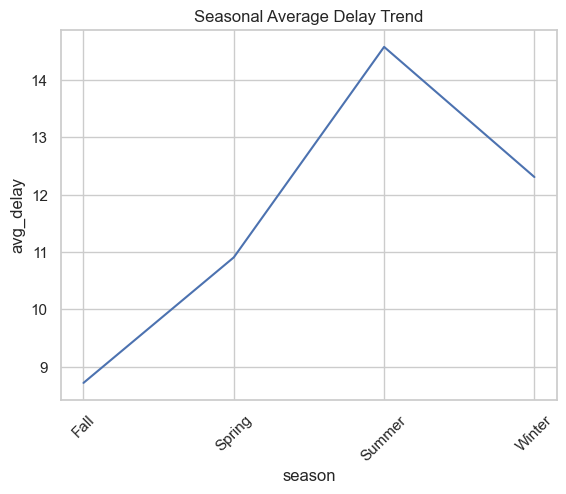

In [36]:
sns.lineplot(data=seasonal_trend, x=seasonal_trend.index, y='avg_delay')
plt.title("Seasonal Average Delay Trend")
plt.xticks(rotation=45)
plt.show()

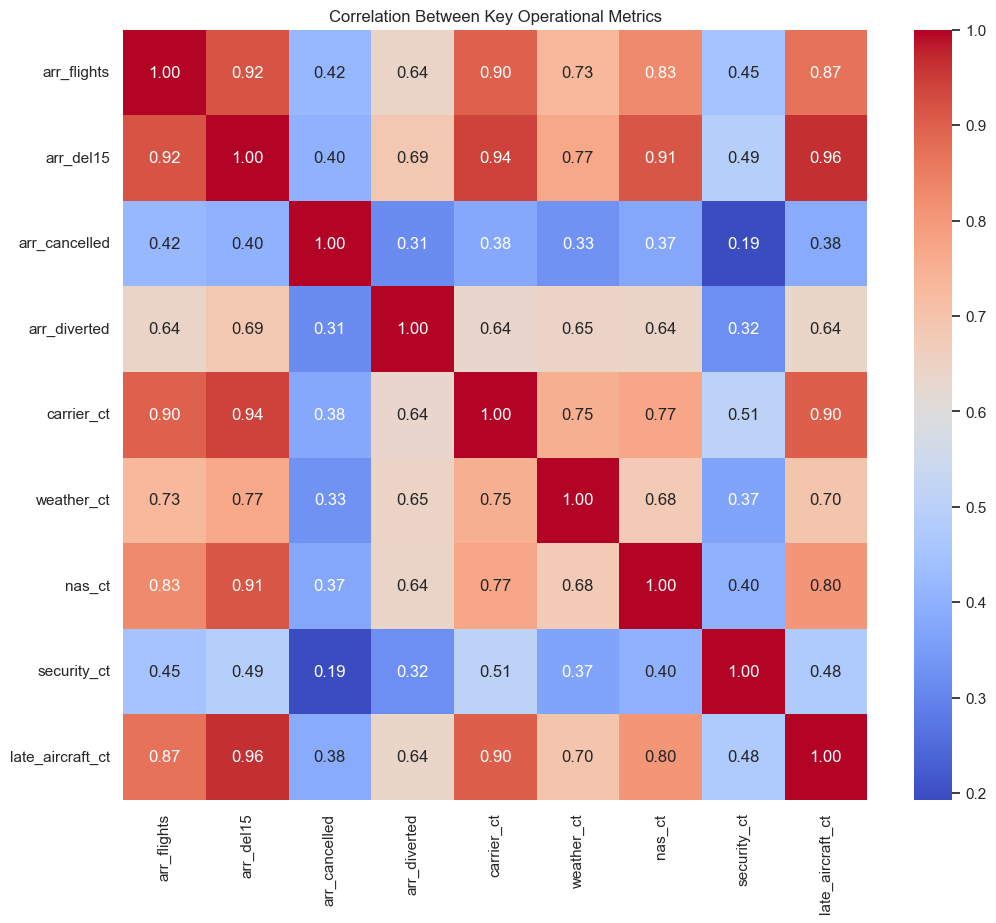

In [37]:
selected_ct_cols = [ 'arr_flights', 'arr_del15', 'arr_cancelled',
                 'arr_diverted', 'carrier_ct',
                 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct' ]

corr = df[selected_ct_cols].corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Operational Metrics")
plt.show()

---

## STEP 3: LOAD

In [38]:
df.shape

(171223, 33)

In [39]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'airport_location', 'date',
       'delay_rate', 'cancellation_rate', 'diverted_rate', 'carrier_rate',
       'weather_rate', 'nas_rate', 'security_rate', 'late_aircraft_rate',
       'month_name', 'season'],
      dtype='object')

In [40]:
df.to_csv('../data/transform.csv')

---

## STEP 4: CONCLUSIONS

1. Data is heavily right skewed probably because this data contains entire collection of airports ranging from small to large
2. Allegeint air had on average the most delays with 14.6 and Hawaiian Air had the least delays with 5.6 
3. Williamsport Regional Airport had on average the most delays with 26.7 and  Inyorken Airport with least delays with 1.15 with minimum 20 flights
4. Average Flight Delay showed an increasing trend since 2013 however tanked at 2020 because of COVID with 5.9 flights and has exponentially increased since with peak at 2023 with 16 flights delays
5. Summer had the most delays peaking in June and Fall had the least tanking in September
6. NAS causes and Carrier causes seem to be the most significant causes of Flight Delays